In [2]:
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
def merge_dfs(dfs:list):
    for i in range(len(dfs)):
        if i==0:
            df=dfs[i]
        else:
            df = pd.merge(df, dfs[i], left_index=True, right_index=True)
    return df

def clean_process(df):
    df=df.where(df!=0,np.nan)                               # - Replace 0 with NaNs
    df=df.dropna()                                          # - Drop NaNs (preliminarily)
    df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
    df=df.interpolate('linear')                             # - Fill resulting NaNs with linear interpolation
    return df

# Load, Process, Align Dates

In [ ]:
folder=r'/Users/igorbykov/Desktop/Thesis/data'

# Get Brent data
name=r'commodities_data_v0.xlsx'
brent = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
brent.index = pd.to_datetime(brent.index) # - TTF Nat Gas Spot; USD (assumed)
brent = clean_process(brent)

# Get TTF data - EUR
name=r'ttf_front_month.xlsx'
ttf = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
ttf.index = pd.to_datetime(ttf.index) # - TTF Nat Gas Spot; USD (assumed)
ttf = clean_process(ttf)

# Utility debt yield index data (10Y)
name=r'utilities_debt.xlsx'
util_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,3],
    index_col=0
    )
util_yield_10y.index = pd.to_datetime(util_yield_10y.index)     # - Ensure datatime indexation
util_yield_10y = clean_process(util_yield_10y)

# Get EUR curve data (10Y)
name=r'euro_curve.xlsx'
govt_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,2],
    index_col=0
    )
govt_yield_10y.index = pd.to_datetime(govt_yield_10y.index)     # - Ensure datatime indexation
govt_yield_10y = clean_process(govt_yield_10y)

/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_16415/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_16415/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_16415/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time

# Duration Assumptions, Convert to Log-Returns, Combine

/Users/igorbykov/opt/anaconda3/envs/quant/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


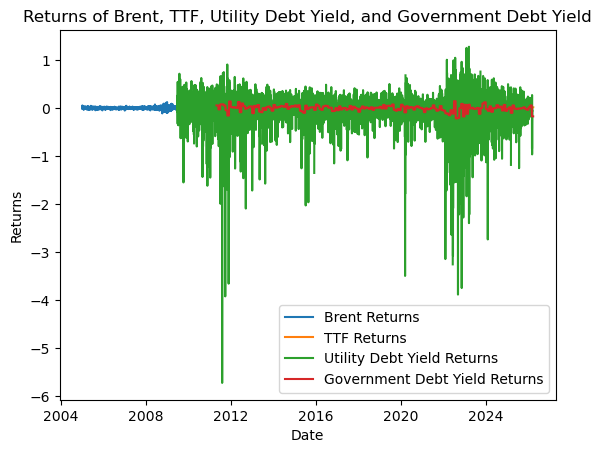

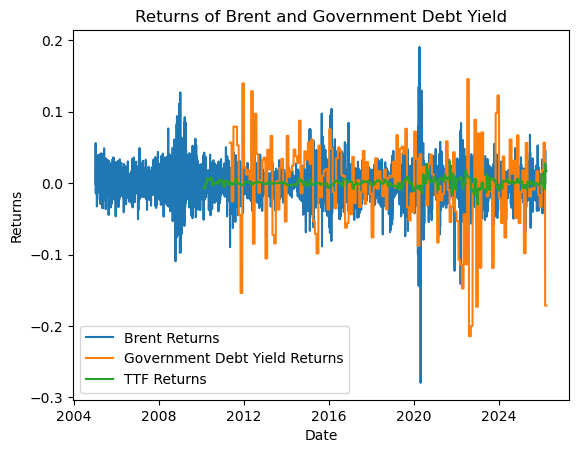

            CO1 Comdty  TTF_front_month  IGEEUA10 BVLI Index       10Y
2011-05-04   -0.010343         0.000844            -0.262664  0.056543
2011-05-11   -0.043969         0.000839            -0.188440  0.056543
2011-05-18    0.020784         0.000834            -0.095960  0.056543
2011-05-25    0.021103         0.000829             0.141065  0.056543
2011-06-01   -0.019027        -0.001948             0.175633 -0.025540


In [6]:
# Convert util yields to returns
# Utility duration will be higher than Govt duration 

D_util = 7.5
D_govt = 8.5

R_util = np.log1p(-D_util * util_yield_10y.diff() )
R_govt = np.log1p(-D_govt * govt_yield_10y.diff() )

R_brent = np.log1p(brent.diff() / brent.shift(1))
R_ttf = np.log1p(ttf.diff() / ttf.shift(1))

df = merge_dfs([R_brent, R_ttf, R_util, R_govt]).dropna()

# Resample frequency
df = df.resample('W-WED').last()

plt.plot(R_brent, label='Brent Returns')
plt.plot(R_ttf, label='TTF Returns')
plt.plot(R_util, label='Utility Debt Yield Returns')
plt.plot(R_govt, label='Government Debt Yield Returns')
plt.legend()
plt.title('Returns of Brent, TTF, Utility Debt Yield, and Government Debt Yield')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

plt.plot(R_brent, label='Brent Returns')
plt.plot(R_govt, label='Government Debt Yield Returns')
plt.plot(R_ttf, label='TTF Returns')
plt.legend()
plt.title('Returns of Brent and Government Debt Yield')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

print(df.head())

# Baseline Unconditional Hedge Model

In [8]:
df['excess_R_util'] = df['IGEEUA10 BVLI Index'] - df['10Y']

In [11]:
unconditional_model_brent = sm.OLS(
    # df['IGEEUA10 BVLI Index'], 
    df['excess_R_util'],
    sm.add_constant(
        df[['10Y','CO1 Comdty']]
        )).fit()

unconditional_model_ttf = sm.OLS(
    # df['IGEEUA10 BVLI Index'], 
    df['excess_R_util'],
    sm.add_constant(
        df[['10Y','TTF_front_month']]
        )).fit()

In [12]:
print(unconditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.802
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.166
Time:                        19:56:16   Log-Likelihood:                -175.99
No. Observations:                 775   AIC:                             358.0
Df Residuals:                     772   BIC:                             371.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0246      0.011     -2.253      0.0

In [13]:
print(unconditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.259
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.105
Time:                        19:56:17   Log-Likelihood:                -175.53
No. Observations:                 775   AIC:                             357.1
Df Residuals:                     772   BIC:                             371.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0244      0.011     

# Regime Identification

In [15]:
ttf

,TTF_front_month
2010-01-29,14.847000
2010-01-30,14.753036
2010-01-31,14.659071
2010-02-01,14.565107
2010-02-02,14.471143
...,...
2026-03-20,50.977440
2026-03-21,51.883080
2026-03-22,52.788720
2026-03-23,53.694360


In [17]:
mu_p_6m_brent = brent.rolling(window=180).mean().dropna()
std_p_6m_brent = brent.rolling(window=180).std().dropna()
threshold_brent = mu_p_6m_brent + 1.5*std_p_6m_brent

mu_p_6m_ttf = ttf.rolling(window=180).mean().dropna()
std_p_6m_ttf = ttf.rolling(window=180).std().dropna()
threshold_ttf = mu_p_6m_ttf + 1.5*std_p_6m_ttf

# threshold will be shorter than brent due to rolling calculation
indicator_brent=pd.Series(data=np.where(brent['CO1 Comdty'].loc[threshold_brent.index] > threshold_brent['CO1 Comdty'], 1, 0), index=threshold_brent.index)
indicator_ttf=pd.Series(data=np.where(ttf['TTF_front_month'].loc[threshold_ttf.index] > threshold_ttf['TTF_front_month'], 1, 0), index=threshold_ttf.index)


# crop indicator to fit into df
indicator_brent = indicator_brent[indicator_brent.index.isin(df.index)]
indicator_ttf = indicator_ttf[indicator_ttf.index.isin(df.index)]
df['D_brent']=indicator_brent
df['D_ttf']=indicator_ttf

df.head(15)

,CO1 Comdty,TTF_front_month,IGEEUA10 BVLI Index,10Y,excess_R_util,D_brent,D_ttf
2011-05-04,-0.010343,0.000844,-0.262664,0.056543,-0.319207,0,0
2011-05-11,-0.043969,0.000839,-0.188440,0.056543,-0.244983,0,0
2011-05-18,0.020784,0.000834,-0.095960,0.056543,-0.152503,0,0
2011-05-25,0.021103,0.000829,0.141065,0.056543,0.084523,0,0
2011-06-01,-0.019027,-0.001948,0.175633,-0.025540,0.201173,0,0
2011-06-08,0.009121,-0.001975,0.273837,-0.025540,0.299377,0,0
2011-06-15,-0.025796,-0.002003,0.248421,-0.025540,0.273961,0,0
2011-06-22,0.028959,-0.002031,0.113998,-0.025540,0.139538,0,0
2011-06-29,0.032736,-0.002061,-0.599202,-0.025540,-0.573662,0,0
2011-07-06,0.000088,-0.000161,0.452508,0.079146,0.373362,0,0


# Conditional Hedge Model

In [18]:
df['govt_indic_brent'] = df['D_brent'] * df['10Y']
df['brent_indic_brent'] = df['D_brent'] * df['CO1 Comdty']

df['govt_indic_ttf'] = df['D_ttf'] * df['10Y']
df['brent_indic_ttf'] = df['D_ttf'] * df['TTF_front_month']

In [19]:
conditional_model_brent = sm.OLS(
    # df['IGEEUA10 BVLI Index'], 
    df['excess_R_util'],
    sm.add_constant(
        df[['10Y', 'govt_indic_brent', 'CO1 Comdty', 'brent_indic_brent']]
        )).fit()

conditional_model_ttf = sm.OLS(
    # df['IGEEUA10 BVLI Index'], 
    df['excess_R_util'],
    sm.add_constant(
        df[['10Y', 'govt_indic_ttf', 'TTF_front_month', 'brent_indic_ttf']]
        )).fit()

In [20]:
print(conditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.294
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0579
Time:                        20:04:00   Log-Likelihood:                -173.20
No. Observations:                 775   AIC:                             356.4
Df Residuals:                     770   BIC:                             379.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0283      0.01

In [21]:
print(conditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.374
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.241
Time:                        20:04:04   Log-Likelihood:                -175.04
No. Observations:                 775   AIC:                             360.1
Df Residuals:                     770   BIC:                             383.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0274      0.012     

# Hedge Effectiveness

In [22]:
HE_unconditional_brent = unconditional_model_brent.rsquared
HE_conditional_brent = conditional_model_brent.rsquared

print(f"Unconditional HE: {HE_unconditional_brent:.4f}")
print(f"Conditional HE: {HE_conditional_brent:.4f}")

Unconditional HE: 0.0046
Conditional HE: 0.0118


In [23]:
HE_unconditional_ttf = unconditional_model_ttf.rsquared
HE_conditional_ttf = conditional_model_ttf.rsquared

print(f"Unconditional HE: {HE_unconditional_ttf:.4f}")
print(f"Conditional HE: {HE_conditional_ttf:.4f}")

Unconditional HE: 0.0058
Conditional HE: 0.0071
